# Notebook 7: PBMC4k → PBMC3k reverse XGBoost validation

This notebook reverses the completed transfer experiment:

```text
Train and tune: PBMC4k / Donor 2
External test: PBMC3k / Donor 1
```

All PBMC3k cells remain external test cells. PBMC4k cross-validation selects the XGBoost settings, after which the model is refit on all PBMC4k cells. The classifier uses normalized expression for genes shared by both datasets; it does not use Harmony coordinates.

The reviewed marker-based labels are evaluation references, not definitive biological ground truth. Accuracy therefore means agreement with those reviewed labels.

## 1. Imports and fixed settings

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    matthews_corrcoef,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", figsize=(6, 5))
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CV_FOLDS = 3
N_SELECTED_GENES = 2000
LOW_CONFIDENCE_THRESHOLD = 0.50
FIGURE_DPI = 180

Matplotlib is building the font cache; this may take a moment.


## 2. Locate inputs and protect the original model

In [2]:
cwd = Path.cwd().resolve()
search_locations = [cwd, *cwd.parents]
root_candidates = []
for location in search_locations:
    root_candidates.extend([location, location / "26-the-backpropagators-analysis"])

ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "PBMC3k" / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad").is_file()
        and (candidate / "PBMC4k" / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad").is_file()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the annotated PBMC3k and PBMC4k inputs. "
        f"Current working directory: {cwd}"
    )

P3_INPUT = ROOT / "PBMC3k" / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad"
P4_INPUT = ROOT / "PBMC4k" / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad"
ORIGINAL_MODEL = ROOT / "PBMC3k" / "models" / "pbmc_cell_classifier.joblib"
INTEGRATED = ROOT / "PBMC_integrated"
MODELS = INTEGRATED / "models"
TABLES = INTEGRATED / "results" / "tables"
FIGURES = INTEGRATED / "results" / "figures"
DATA_OUT = INTEGRATED / "data" / "processed"
for directory in (MODELS, TABLES, FIGURES, DATA_OUT):
    directory.mkdir(parents=True, exist_ok=True)

MODEL_OUT = MODELS / "pbmc4k_reverse_xgboost.joblib"
METADATA_OUT = MODELS / "pbmc4k_reverse_xgboost_metadata.json"
PREDICTION_OUT = DATA_OUT / "pbmc3k_reverse_xgboost_external_validation.h5ad"
original_model_hash_before = hashlib.sha256(ORIGINAL_MODEL.read_bytes()).hexdigest()

print(f"Repository root: {ROOT}")
print(f"Original PBMC3k model SHA-256: {original_model_hash_before}")

Repository root: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis
Original PBMC3k model SHA-256: cc8701edbb1b3726d788307acf8384e213594f414d47c3edf24eebc257ea1465


## 3. Load labels and construct the shared-gene matrices

Both `.raw` matrices contain normalized, log-transformed all-gene expression. Gene names are aligned explicitly, so training and external-test columns have identical meanings and order.

In [3]:
pbmc3k = sc.read_h5ad(P3_INPUT)
pbmc4k = sc.read_h5ad(P4_INPUT)
for name, adata in {"PBMC3k": pbmc3k, "PBMC4k": pbmc4k}.items():
    if adata.raw is None or "cell_type" not in adata.obs:
        raise ValueError(f"{name} must contain .raw normalized expression and reviewed cell_type labels.")

p3_genes = pd.Index(pbmc3k.raw.var_names.astype(str))
p4_genes = pd.Index(pbmc4k.raw.var_names.astype(str))
shared_genes = pd.Index([gene for gene in p4_genes if gene in set(p3_genes)])
if not shared_genes.is_unique:
    raise ValueError("Shared gene names must be unique.")

X_train = pbmc4k.raw[:, shared_genes].X.astype(np.float64)
X_external = pbmc3k.raw[:, shared_genes].X.astype(np.float64)
X_train = sparse.csr_matrix(X_train)
X_external = sparse.csr_matrix(X_external)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(pbmc4k.obs["cell_type"].astype(str))
model_classes = label_encoder.classes_
external_true_labels = pbmc3k.obs["cell_type"].astype(str).to_numpy()
external_classes = np.sort(np.unique(external_true_labels))
shared_classes = np.asarray([label for label in model_classes if label in set(external_classes)])
unseen_external_classes = np.asarray([label for label in external_classes if label not in set(model_classes)])

class_schema = pd.DataFrame({
    "cell_type": sorted(set(model_classes).union(external_classes)),
}).assign(
    present_in_pbmc4k_training=lambda x: x["cell_type"].isin(model_classes),
    present_in_pbmc3k_external_test=lambda x: x["cell_type"].isin(external_classes),
)
display(class_schema)
print(f"PBMC4k training cells: {pbmc4k.n_obs:,}")
print(f"PBMC3k external-test cells: {pbmc3k.n_obs:,}")
print(f"Shared normalized genes: {len(shared_genes):,}")
print(f"Shared cell types: {len(shared_classes)}")
print(f"Unseen PBMC3k classes: {list(unseen_external_classes)}")

,cell_type,present_in_pbmc4k_training,present_in_pbmc3k_external_test
0,Activated/transitional T cells,True,True
1,B cells,True,True
2,CD16+ non-classical monocytes,True,True
3,Classical monocytes,True,True
4,Cytotoxic CD8 T cells,True,True
5,Dendritic cells,True,False
6,IL7R+ memory/helper T cells,True,True
7,NK cells,True,True
8,Naive/resting T cells,True,True
9,Platelets,False,True


PBMC4k training cells: 4,131
PBMC3k external-test cells: 2,638
Shared normalized genes: 12,897
Shared cell types: 8
Unseen PBMC3k classes: [np.str_('Platelets')]


## 4. Tune XGBoost inside PBMC4k only

Variance filtering and selection of the strongest 2,000 genes happen inside each cross-validation fold. PBMC3k is not used for feature scoring, parameter selection, confidence thresholds, or model selection. Cross-validation is a tuning estimate, not an independent PBMC4k test score.

In [4]:
pipeline = Pipeline([
    ("variance", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=min(N_SELECTED_GENES, X_train.shape[1]))),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=250,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
parameter_grid = {
    "classifier__max_depth": [3, 6],
    "classifier__learning_rate": [0.05, 0.1],
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    pipeline,
    parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
    error_score="raise",
    verbose=1,
)
search.fit(X_train, y_train)
reverse_model = search.best_estimator_

cv_results = pd.DataFrame(search.cv_results_)[[
    "rank_test_score", "mean_test_score", "std_test_score", "params",
]].sort_values("rank_test_score")
cv_results["params"] = cv_results["params"].map(lambda value: json.dumps(value, sort_keys=True))
cv_results.to_csv(TABLES / "pbmc_reverse_xgboost_cv_results.csv", index=False)
display(cv_results)
print(f"Best PBMC4k CV macro-F1: {search.best_score_:.4f}")
print("Selected settings:", search.best_params_)
print("The selected pipeline has now been refit on all PBMC4k cells.")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,rank_test_score,mean_test_score,std_test_score,params
1,1,0.942291,0.003461,"{""classifier__learning_rate"": 0.05, ""classifie..."
3,2,0.939300,0.005362,"{""classifier__learning_rate"": 0.1, ""classifier..."
2,3,0.939255,0.006062,"{""classifier__learning_rate"": 0.1, ""classifier..."
0,4,0.937898,0.005381,"{""classifier__learning_rate"": 0.05, ""classifie..."


Best PBMC4k CV macro-F1: 0.9423
Selected settings: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6}
The selected pipeline has now been refit on all PBMC4k cells.


## 5. Predict every PBMC3k cell

In [5]:
encoded_predictions = np.asarray(reverse_model.predict(X_external), dtype=int)
probabilities = np.asarray(reverse_model.predict_proba(X_external), dtype=float)
predicted_labels = model_classes[encoded_predictions]
max_probability = probabilities.max(axis=1)
normalized_entropy = -np.sum(
    probabilities * np.log(np.clip(probabilities, 1e-12, 1.0)), axis=1
) / np.log(probabilities.shape[1])
known_to_model = np.isin(external_true_labels, model_classes)
prediction_correct = predicted_labels == external_true_labels

prediction_frame = pd.DataFrame({
    "cell_id": pbmc3k.obs_names.astype(str),
    "leiden": pbmc3k.obs["leiden"].astype(str).to_numpy(),
    "reviewed_cell_type": external_true_labels,
    "predicted_cell_type": predicted_labels,
    "model_knows_reviewed_class": known_to_model,
    "prediction_matches_reviewed_label": prediction_correct,
    "max_probability": max_probability,
    "normalized_probability_entropy": normalized_entropy,
    "low_confidence": max_probability < LOW_CONFIDENCE_THRESHOLD,
})
for index, class_name in enumerate(model_classes):
    prediction_frame[f"probability__{class_name}"] = probabilities[:, index]
prediction_frame.to_csv(TABLES / "pbmc_reverse_xgboost_cell_predictions.csv", index=False)
display(prediction_frame.head())

,cell_id,leiden,reviewed_cell_type,predicted_cell_type,model_knows_reviewed_class,prediction_matches_reviewed_label,max_probability,normalized_probability_entropy,low_confidence,probability__Activated/transitional T cells,probability__B cells,probability__CD16+ non-classical monocytes,probability__Classical monocytes,probability__Cytotoxic CD8 T cells,probability__Dendritic cells,probability__IL7R+ memory/helper T cells,probability__NK cells,probability__Naive/resting T cells
0,AAACATACAACCAC-1,0,Cytotoxic CD8 T cells,Activated/transitional T cells,True,False,0.711383,0.386308,False,0.711383,0.002616,0.001777,0.004235,0.211048,0.001761,0.056941,0.004484,0.005754
1,AAACATTGAGCTAC-1,1,B cells,B cells,True,True,0.998889,0.004708,False,0.000286,0.998889,0.000029,0.000036,0.000099,0.000024,0.000511,0.000021,0.000106
2,AAACATTGATCAGC-1,2,IL7R+ memory/helper T cells,IL7R+ memory/helper T cells,True,True,0.985931,0.043472,False,0.007045,0.000726,0.000497,0.000899,0.003051,0.000524,0.985931,0.000503,0.000823
3,AAACCGTGCTTCCG-1,3,Classical monocytes,Classical monocytes,True,True,0.890629,0.177542,False,0.001964,0.001613,0.101030,0.890629,0.000943,0.000487,0.001654,0.001027,0.000653
4,AAACCGTGTATGCG-1,5,NK cells,NK cells,True,True,0.980910,0.056682,False,0.003789,0.000703,0.000482,0.001250,0.009348,0.001433,0.001131,0.980910,0.000952


## 6. External-test metrics

Shared-class metrics exclude the 11 PBMC3k platelets because PBMC4k provided no platelet training class. The all-cell forced-choice score includes them and therefore records every platelet as incorrect. Confidence is only the model's strongest class probability; it is not a guarantee of correctness or a calibrated biological probability.

In [6]:
true_shared = external_true_labels[known_to_model]
pred_shared = predicted_labels[known_to_model]
shared_labels_present = [label for label in model_classes if label in set(true_shared)]

external_metrics = pd.Series({
    "PBMC3k cells evaluated": pbmc3k.n_obs,
    "shared-class PBMC3k cells": int(known_to_model.sum()),
    "unseen-class PBMC3k cells": int((~known_to_model).sum()),
    "all-cell forced-choice accuracy": accuracy_score(external_true_labels, predicted_labels),
    "shared-class accuracy": accuracy_score(true_shared, pred_shared),
    "shared-class balanced accuracy": balanced_accuracy_score(true_shared, pred_shared),
    "shared-class macro F1": f1_score(
        true_shared, pred_shared, labels=shared_labels_present, average="macro", zero_division=0
    ),
    "shared-class weighted F1": f1_score(true_shared, pred_shared, average="weighted", zero_division=0),
    "shared-class MCC": matthews_corrcoef(true_shared, pred_shared),
    "mean maximum probability": max_probability.mean(),
    "median maximum probability": np.median(max_probability),
    "low-confidence cells": int((max_probability < LOW_CONFIDENCE_THRESHOLD).sum()),
    "low-confidence percent": 100 * np.mean(max_probability < LOW_CONFIDENCE_THRESHOLD),
    "PBMC4k training CV macro F1": search.best_score_,
}, name="PBMC4k to PBMC3k external validation")
external_metrics.to_csv(TABLES / "pbmc_reverse_xgboost_external_metrics.csv")
display(external_metrics.to_frame())

report = classification_report(
    true_shared,
    pred_shared,
    labels=list(model_classes),
    output_dict=True,
    zero_division=0,
)
per_class_report = pd.DataFrame(report).T
per_class_report.to_csv(TABLES / "pbmc_reverse_xgboost_per_class_report.csv")
display(per_class_report.round(3))

/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,PBMC4k to PBMC3k external validation
PBMC3k cells evaluated,2638.000000
shared-class PBMC3k cells,2627.000000
unseen-class PBMC3k cells,11.000000
all-cell forced-choice accuracy,0.689538
shared-class accuracy,0.692425
shared-class balanced accuracy,0.726054
shared-class macro F1,0.690563
shared-class weighted F1,0.700483
shared-class MCC,0.680795
mean maximum probability,0.915845


,precision,recall,f1-score,support
Activated/transitional T cells,0.092,0.500,0.156,128.000
B cells,0.997,0.977,0.987,348.000
CD16+ non-classical monocytes,0.947,0.942,0.944,171.000
Classical monocytes,0.980,0.980,0.980,502.000
Cytotoxic CD8 T cells,0.681,0.908,0.779,273.000
Dendritic cells,0.000,0.000,0.000,0.000
IL7R+ memory/helper T cells,0.951,0.610,0.743,602.000
NK cells,0.879,0.856,0.868,153.000
Naive/resting T cells,0.889,0.036,0.068,450.000
accuracy,0.692,0.692,0.692,0.692


## 7. Confusion matrices and the unseen platelet population

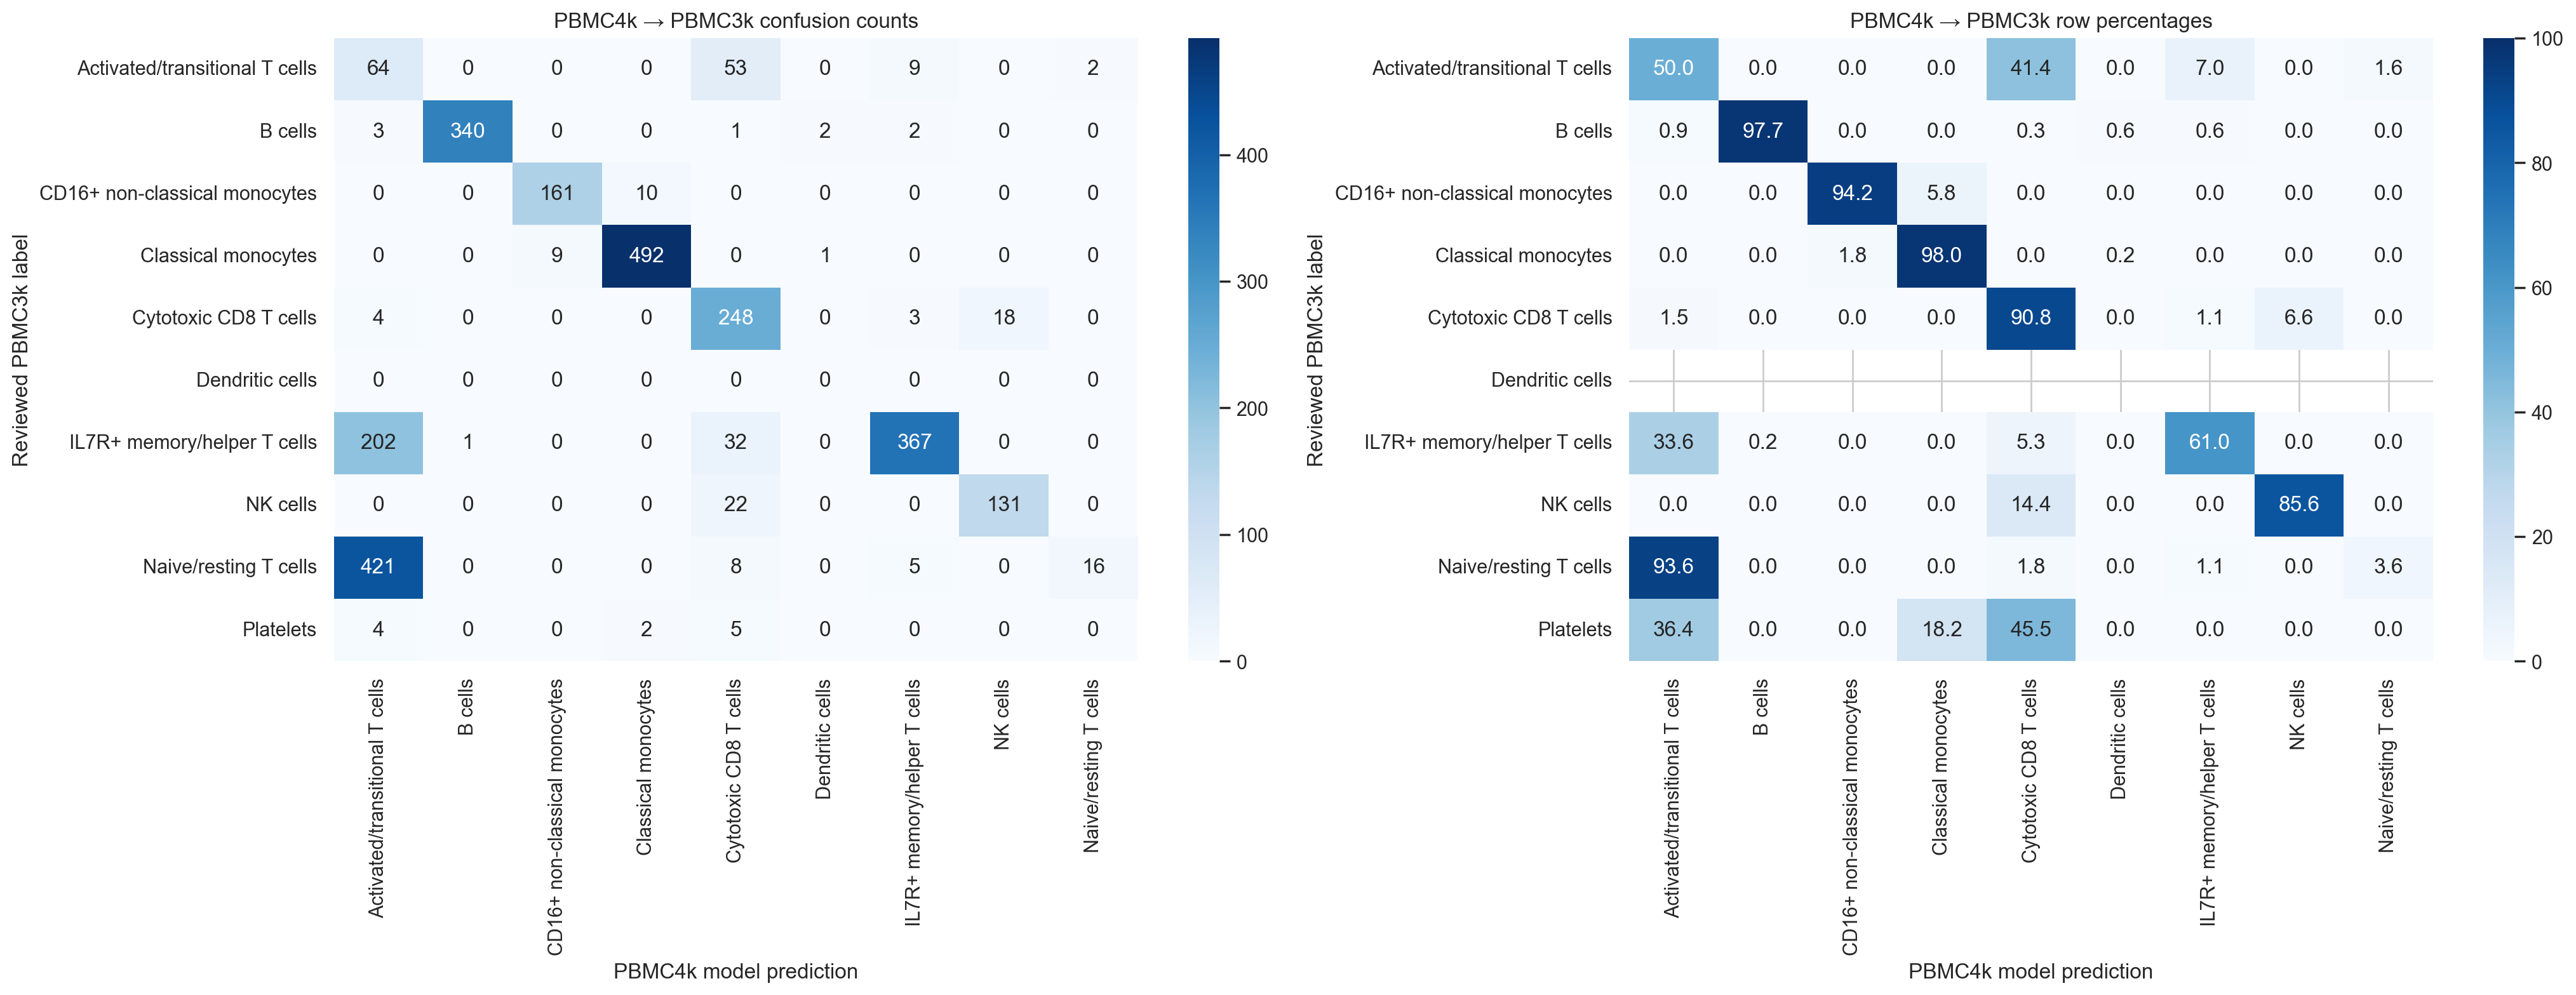

,reviewed_cell_type,predicted_cell_type,cells,mean_max_probability,median_max_probability,low_confidence_cells,percent_within_reviewed_class
0,Platelets,Activated/transitional T cells,4,0.392348,0.391655,4,36.363636
1,Platelets,Classical monocytes,2,0.737852,0.737852,1,18.181818
2,Platelets,Cytotoxic CD8 T cells,5,0.361012,0.322344,5,45.454545


,,cells,mean_max_probability,median_max_probability,low_confidence_percent
reviewed_cell_type,model_knows_reviewed_class,,,,
Activated/transitional T cells,True,128,0.813,0.883,5.469
B cells,True,348,0.988,0.999,0.000
CD16+ non-classical monocytes,True,171,0.953,0.992,0.585
Classical monocytes,True,502,0.982,0.999,0.199
Cytotoxic CD8 T cells,True,273,0.954,0.991,0.366
IL7R+ memory/helper T cells,True,602,0.807,0.861,5.316
NK cells,True,153,0.939,0.991,0.654
Naive/resting T cells,True,450,0.927,0.987,1.333
Platelets,False,11,0.441,0.419,90.909


In [7]:
true_display_order = list(model_classes) + [
    label for label in unseen_external_classes if label not in set(model_classes)
]
confusion_counts = pd.crosstab(
    pd.Categorical(external_true_labels, categories=true_display_order, ordered=True),
    pd.Categorical(predicted_labels, categories=model_classes, ordered=True),
    rownames=["Reviewed PBMC3k label"],
    colnames=["PBMC4k model prediction"],
    dropna=False,
)
confusion_row_percent = confusion_counts.div(confusion_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
confusion_counts.to_csv(TABLES / "pbmc_reverse_xgboost_confusion_counts.csv")
confusion_row_percent.to_csv(TABLES / "pbmc_reverse_xgboost_confusion_row_percent.csv")

fig, axes = plt.subplots(1, 2, figsize=(21, 8))
sns.heatmap(confusion_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("PBMC4k → PBMC3k confusion counts")
sns.heatmap(confusion_row_percent, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, ax=axes[1])
axes[1].set_title("PBMC4k → PBMC3k row percentages")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_reverse_xgboost_confusion_matrices.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

unseen_behavior = (
    prediction_frame.loc[~known_to_model]
    .groupby(["reviewed_cell_type", "predicted_cell_type"], observed=True)
    .agg(
        cells=("predicted_cell_type", "size"),
        mean_max_probability=("max_probability", "mean"),
        median_max_probability=("max_probability", "median"),
        low_confidence_cells=("low_confidence", "sum"),
    )
    .reset_index()
)
if not unseen_behavior.empty:
    unseen_behavior["percent_within_reviewed_class"] = (
        100 * unseen_behavior["cells"] / unseen_behavior.groupby("reviewed_cell_type")["cells"].transform("sum")
    )
unseen_behavior.to_csv(TABLES / "pbmc_reverse_xgboost_unseen_platelet_behavior.csv", index=False)
display(unseen_behavior)

confidence_summary = (
    prediction_frame.groupby(["reviewed_cell_type", "model_knows_reviewed_class"], observed=True)
    .agg(
        cells=("max_probability", "size"),
        mean_max_probability=("max_probability", "mean"),
        median_max_probability=("max_probability", "median"),
        low_confidence_percent=("low_confidence", "mean"),
    )
)
confidence_summary["low_confidence_percent"] *= 100
confidence_summary.to_csv(TABLES / "pbmc_reverse_xgboost_confidence_by_reviewed_type.csv")
display(confidence_summary.round(3))

## 8. UMAP review and bidirectional comparison

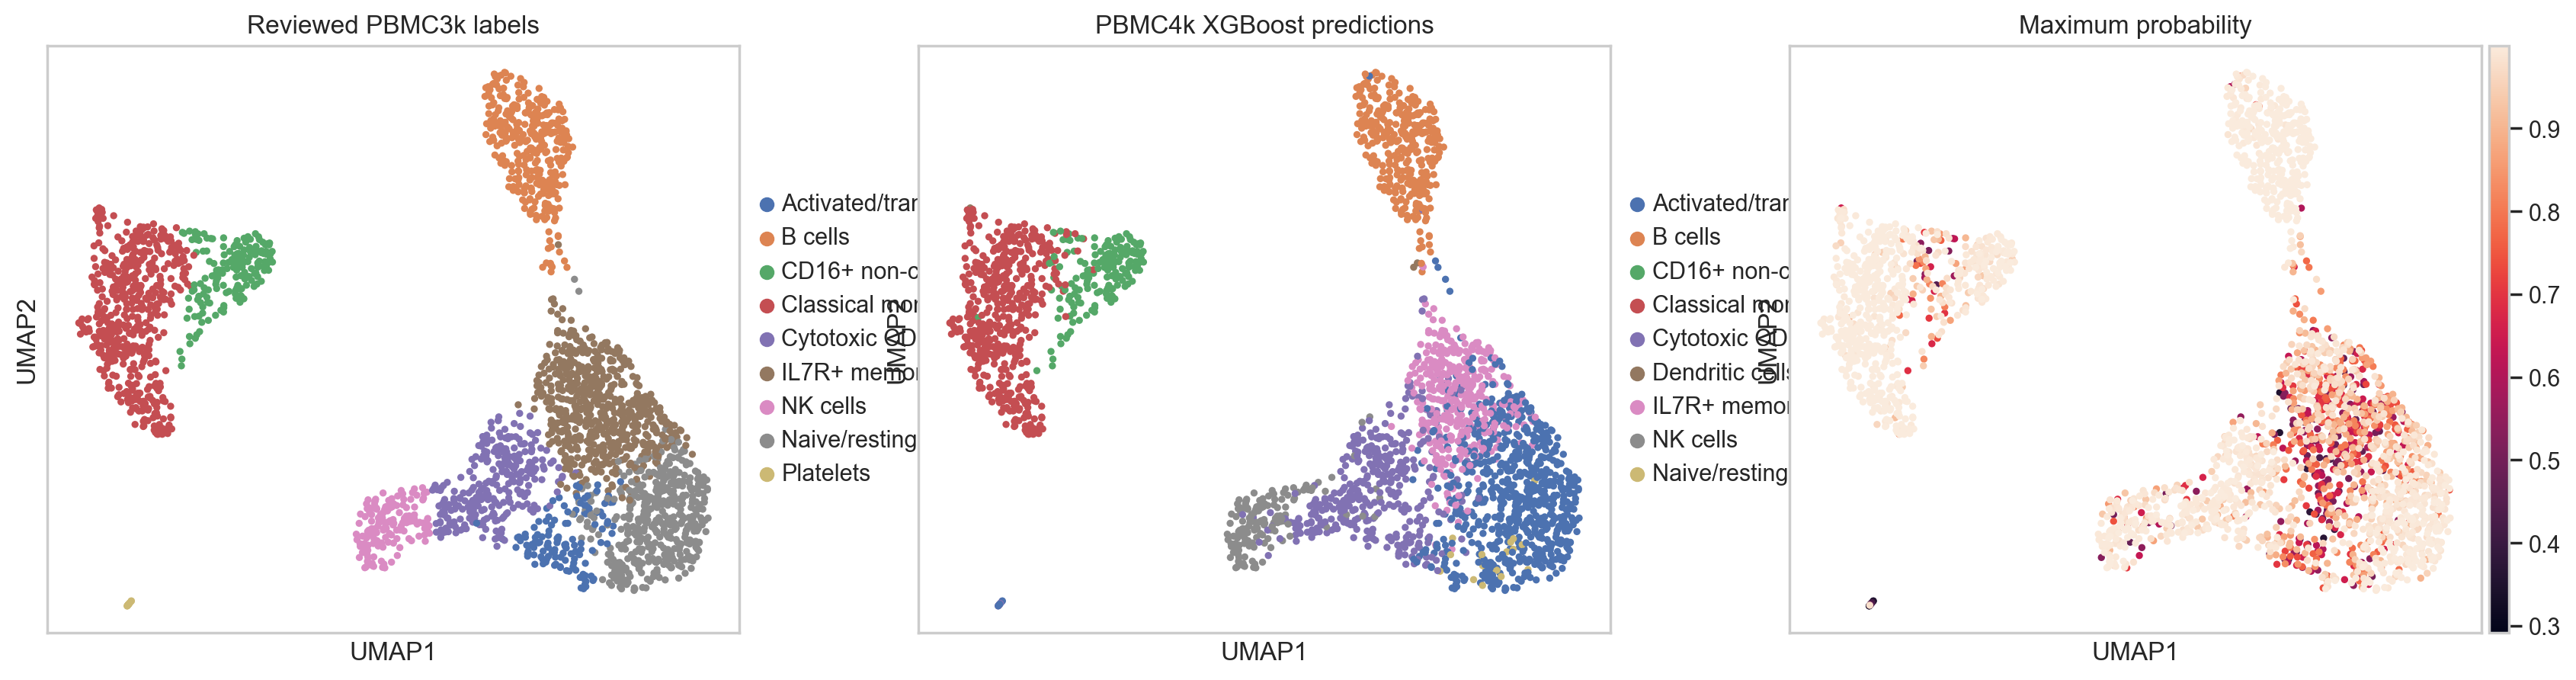

,evaluation,training_cells,external_test_cells,shared_class_accuracy,shared_class_macro_f1,unseen_external_class,feature_schema
0,PBMC3k → PBMC4k,2638,4131,0.692458,0.715813,Dendritic cells,Original PBMC3k model genes
1,PBMC4k → PBMC3k,4131,2638,0.692425,0.690563,Platelets,PBMC3k/PBMC4k shared genes


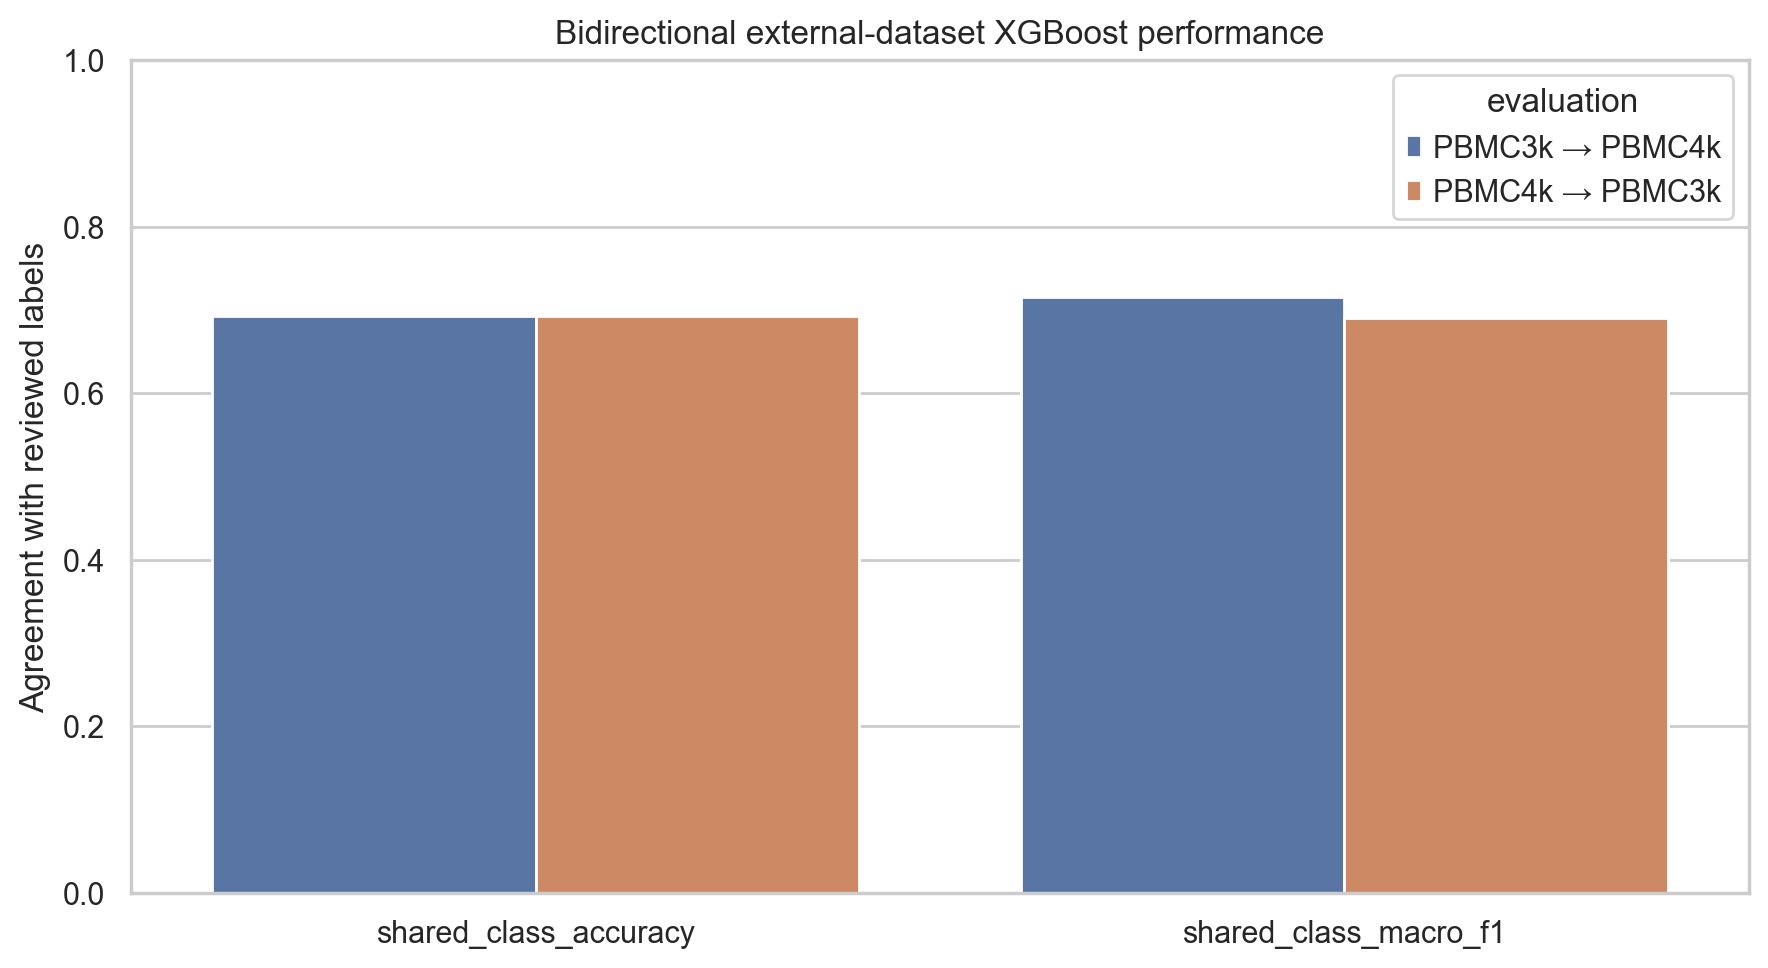

In [8]:
pbmc3k.obs["reverse_xgboost_prediction"] = pd.Categorical(predicted_labels, categories=model_classes)
pbmc3k.obs["reverse_xgboost_max_probability"] = max_probability
pbmc3k.obs["reverse_xgboost_low_confidence"] = max_probability < LOW_CONFIDENCE_THRESHOLD
pbmc3k.obs["reverse_xgboost_prediction_correct"] = prediction_correct
pbmc3k.obs["reverse_xgboost_reviewed_class_known"] = known_to_model

sc.pl.umap(
    pbmc3k,
    color=["cell_type", "reverse_xgboost_prediction", "reverse_xgboost_max_probability"],
    ncols=3,
    title=["Reviewed PBMC3k labels", "PBMC4k XGBoost predictions", "Maximum probability"],
    show=False,
)
plt.savefig(FIGURES / "pbmc_reverse_xgboost_prediction_umaps.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

forward_metrics_path = ROOT / "PBMC4k" / "results" / "tables" / "pbmc4k_phase4_xgboost_external_metrics.csv"
forward_metrics = pd.read_csv(forward_metrics_path, index_col=0).iloc[:, 0]
bidirectional = pd.DataFrame({
    "evaluation": ["PBMC3k → PBMC4k", "PBMC4k → PBMC3k"],
    "training_cells": [pbmc3k.n_obs, pbmc4k.n_obs],
    "external_test_cells": [pbmc4k.n_obs, pbmc3k.n_obs],
    "shared_class_accuracy": [forward_metrics["shared-class accuracy"], external_metrics["shared-class accuracy"]],
    "shared_class_macro_f1": [forward_metrics["shared-class macro F1"], external_metrics["shared-class macro F1"]],
    "unseen_external_class": ["Dendritic cells", "Platelets"],
    "feature_schema": ["Original PBMC3k model genes", "PBMC3k/PBMC4k shared genes"],
})
bidirectional.to_csv(TABLES / "pbmc_bidirectional_xgboost_external_comparison.csv", index=False)
display(bidirectional)

comparison_long = bidirectional.melt(
    id_vars="evaluation",
    value_vars=["shared_class_accuracy", "shared_class_macro_f1"],
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_long, x="metric", y="score", hue="evaluation")
plt.ylim(0, 1)
plt.title("Bidirectional external-dataset XGBoost performance")
plt.ylabel("Agreement with reviewed labels")
plt.xlabel("")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_bidirectional_xgboost_external_comparison.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## 9. Save the reverse model and external prediction object

These are new integrated-project artifacts. The frozen PBMC3k model and both donor-specific annotated inputs remain unchanged.

In [9]:
variance_mask = reverse_model.named_steps["variance"].get_support()
genes_after_variance = shared_genes.to_numpy()[variance_mask]
selected_mask = reverse_model.named_steps["select"].get_support()
selected_genes = genes_after_variance[selected_mask]

joblib.dump(reverse_model, MODEL_OUT)
reverse_model_hash = hashlib.sha256(MODEL_OUT.read_bytes()).hexdigest()
metadata = {
    "model": "XGBoost",
    "experiment": "PBMC4k / Donor 2 training to PBMC3k / Donor 1 external test",
    "training_cells": int(pbmc4k.n_obs),
    "external_test_cells": int(pbmc3k.n_obs),
    "classes": model_classes.tolist(),
    "gene_names": shared_genes.tolist(),
    "selected_genes": selected_genes.tolist(),
    "normalization": "per-cell normalize_total target_sum=10000 followed by log1p in donor notebooks",
    "feature_selection": "VarianceThreshold then training-only SelectKBest(f_classif, k=2000)",
    "harmony_coordinates_used": False,
    "cv_folds": CV_FOLDS,
    "cv_primary_metric": "macro F1",
    "best_cv_macro_f1": float(search.best_score_),
    "best_parameters": search.best_params_,
    "shared_class_external_accuracy": float(external_metrics["shared-class accuracy"]),
    "shared_class_external_macro_f1": float(external_metrics["shared-class macro F1"]),
    "unseen_external_classes": unseen_external_classes.tolist(),
    "label_interpretation": "Human-reviewed marker-based proxy labels, not definitive biological ground truth",
    "model_sha256": reverse_model_hash,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
METADATA_OUT.write_text(json.dumps(metadata, indent=2) + "\n")

original_model_hash_after = hashlib.sha256(ORIGINAL_MODEL.read_bytes()).hexdigest()
if original_model_hash_after != original_model_hash_before:
    raise RuntimeError("The original PBMC3k model changed during reverse validation.")

pbmc3k.uns["reverse_xgboost_external_validation"] = {
    "training_donor": "PBMC4k / Donor 2",
    "external_test_donor": "PBMC3k / Donor 1",
    "pbmc3k_split": "none; every annotated PBMC3k cell is external test data",
    "model_path": str(MODEL_OUT),
    "model_sha256": reverse_model_hash,
    "shared_class_accuracy": float(external_metrics["shared-class accuracy"]),
    "shared_class_macro_f1": float(external_metrics["shared-class macro F1"]),
    "unseen_pbmc3k_classes": unseen_external_classes.tolist(),
    "marker_labels_are_definitive_ground_truth": False,
}
pbmc3k.write_h5ad(PREDICTION_OUT, compression="gzip")

print(f"Saved reverse model: {MODEL_OUT}")
print(f"Saved metadata: {METADATA_OUT}")
print(f"Saved PBMC3k external predictions: {PREDICTION_OUT}")
print(f"Original PBMC3k model preserved: {original_model_hash_after}")

Saved reverse model: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/models/pbmc4k_reverse_xgboost.joblib
Saved metadata: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/models/pbmc4k_reverse_xgboost_metadata.json
Saved PBMC3k external predictions: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/data/processed/pbmc3k_reverse_xgboost_external_validation.h5ad
Original PBMC3k model preserved: cc8701edbb1b3726d788307acf8384e213594f414d47c3edf24eebc257ea1465


## Interpretation checklist

- PBMC3k was never used to tune the reverse model.
- The external result measures agreement with reviewed marker-based labels, not absolute biological truth.
- Platelets are an unknown class and must be interpreted separately.
- Maximum probability is uncalibrated confidence and can be high for an incorrect or unknown-class prediction.
- The two transfer directions use different feature schemas, which is recorded in the comparison table.
- Harmony coordinates were not classifier features.
- A future combined model will need a third dataset for a genuinely untouched final evaluation.